# K-Means

En este notebook veremos cómo funciona **K-Means**, uno de los algoritmos de clustering más conocidos.

**Idea clave**:
- Queremos agrupar datos en **K clusters**
- Cada cluster tiene un **centroide**
- Cada punto se asigna al centroide más cercano


In [56]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 1. Generación de datos

Creamos un conjunto de datos con varios grupos para ver cómo los detecta K-Means.

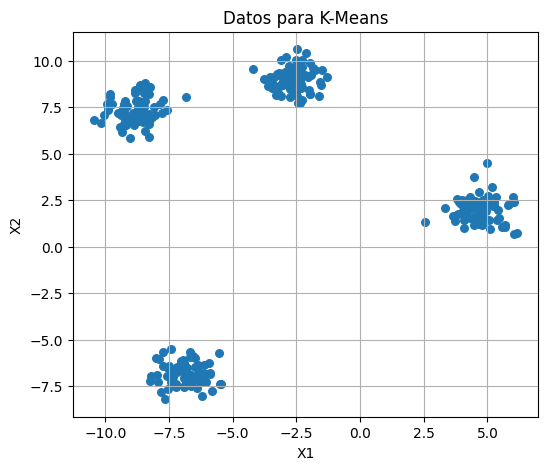

In [57]:
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.65,
    random_state=42
)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=30)
plt.title('Datos para K-Means')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

## 2. Entrenamiento del modelo

Elegimos un valor de `K` y ajustamos el modelo.

In [58]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

sil = silhouette_score(X, labels)

print(f'Silhouette score: {sil:.4f}')

Silhouette score: 0.8651


## Silhouette Score

El **Silhouette Score** mide la calidad de un clustering evaluando qué tan bien está asignado cada punto a su grupo.

Tiene en cuenta dos ideas:
- qué tan cerca está un punto de los demás puntos de su mismo cluster
- qué tan lejos está de los puntos de otros clusters

Su valor está entre **-1 y 1**:
- valores cercanos a **1** → clustering bien definido
- valores cercanos a **0** → clusters poco claros o solapados
- valores negativos → puntos mal asignados

En general, cuanto mayor sea el Silhouette Score, mejor es la calidad del clustering.

## 3. Visualización de los clusters

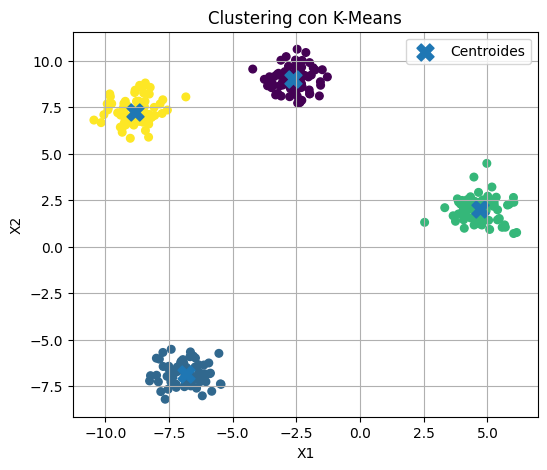

In [59]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:,0], centroids[:,1], s=150, marker='X', label='Centroides')
plt.title('Clustering con K-Means')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()

## 4. Comparación de distintos valores de K

Vamos a probar varios valores de `K` para ver cómo cambia el resultado.

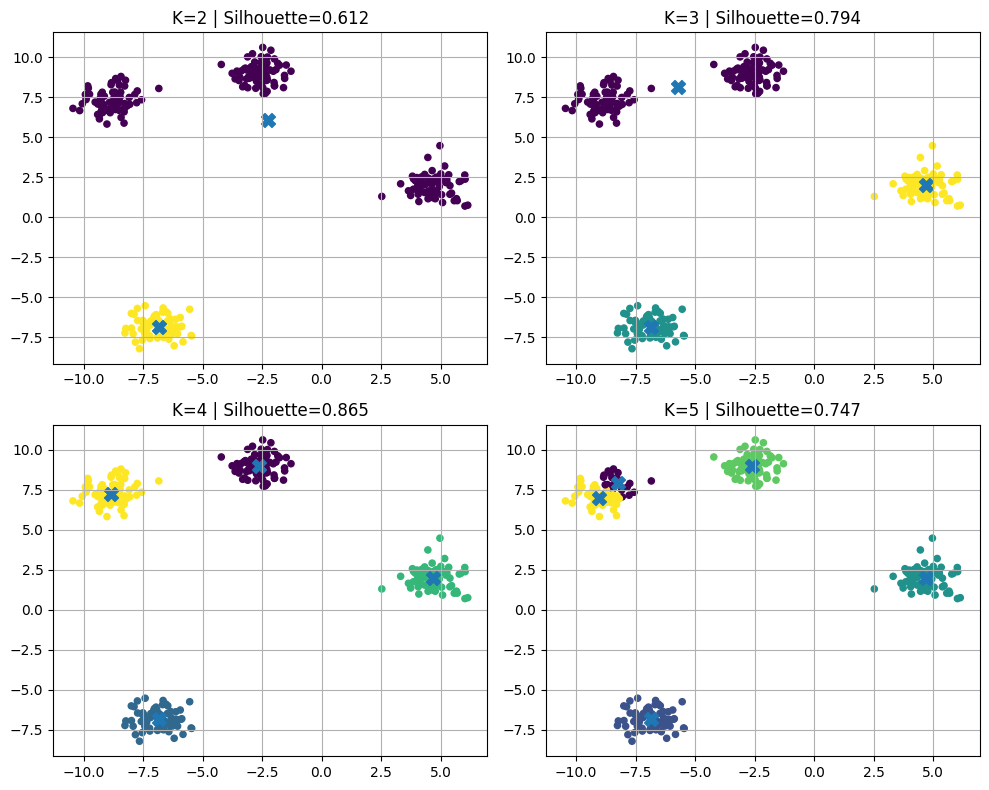

In [60]:
ks = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, k in enumerate(ks):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    labels_k = model.labels_
    centroids_k = model.cluster_centers_
    sil_k = silhouette_score(X, labels_k)

    axes[i].scatter(X[:,0], X[:,1], c=labels_k, cmap='viridis', s=20)
    axes[i].scatter(centroids_k[:,0], centroids_k[:,1], s=100, marker='X')
    axes[i].set_title(f'K={k} | Silhouette={sil_k:.3f}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 5. Inercia

K-Means intenta minimizar la distancia de los puntos a sus centroides.

La **inercia** mide esa dispersión interna: cuanto menor, más compactos son los clusters.

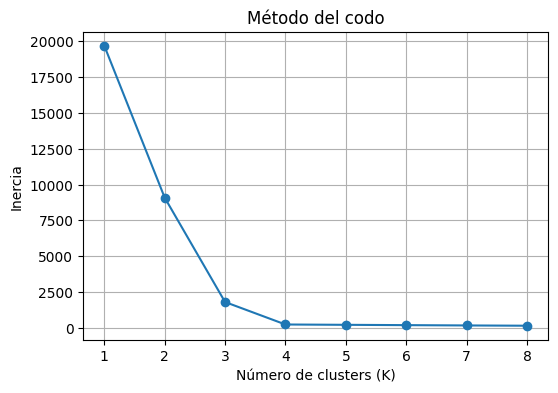

In [61]:
ks = range(1, 9)
inercias = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inercias.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inercias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()

Con el método del codo, si no fuese visualmente tan evidente el número de clusters, podríamos elegir el **K**

## 6. Idea importante

K-Means repite este proceso:

1. Inicializa centroides
2. Asigna cada punto al centroide más cercano
3. Recalcula los centroides
4. Repite hasta converger


## 7. Conclusiones

- K-Means agrupa datos alrededor de centroides
- Necesita elegir el número de clusters `K`
- Funciona bien cuando los grupos son compactos y regulares
- No detecta ruido ni formas muy complejas tan bien como otros métodos


## 8. Ejercicios

1. Probar otros valores de `K`
2. Comparar el silhouette score para distintos `K`
3. Explicar qué representa cada centroide
4. Observar en qué punto el método del codo parece más razonable


Usa estos datos

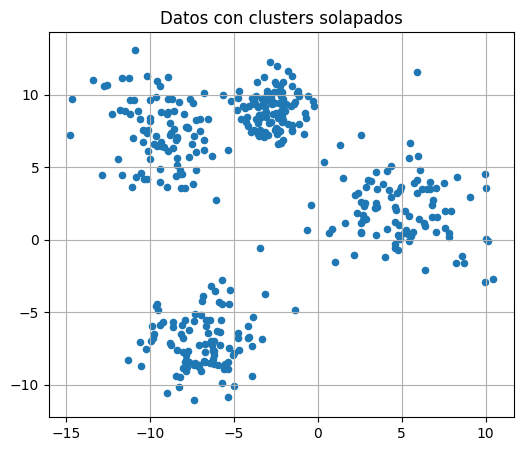

In [62]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=[1.2, 2.5, 1.8, 2.2],  # 👈 distinta dispersión
    random_state=42
)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=20)
plt.title("Datos con clusters solapados")
plt.grid(True)
plt.show()

In [63]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

sil = silhouette_score(X, labels)

print(f'Silhouette score: {sil:.4f}')

Silhouette score: 0.6412


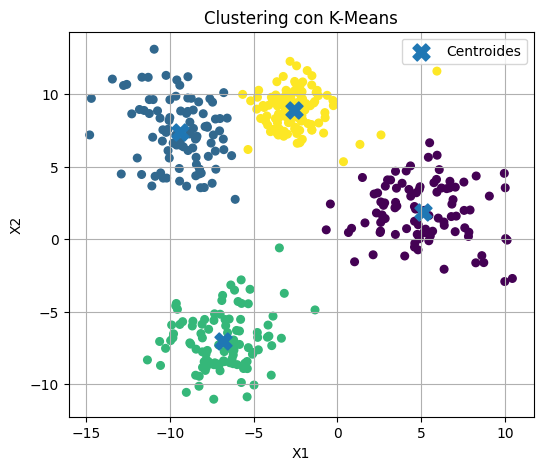

In [64]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:,0], centroids[:,1], s=150, marker='X', label='Centroides')
plt.title('Clustering con K-Means')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()

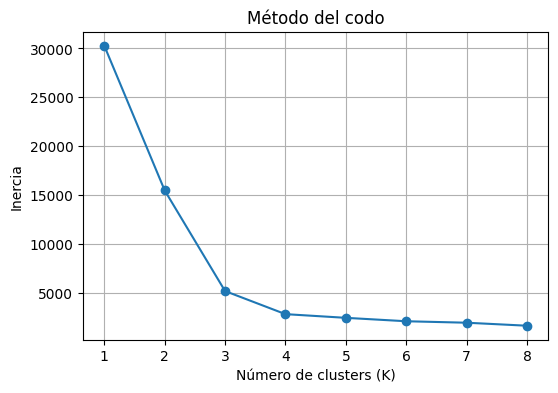

In [65]:
ks = range(1, 9)
inercias = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inercias.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inercias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()

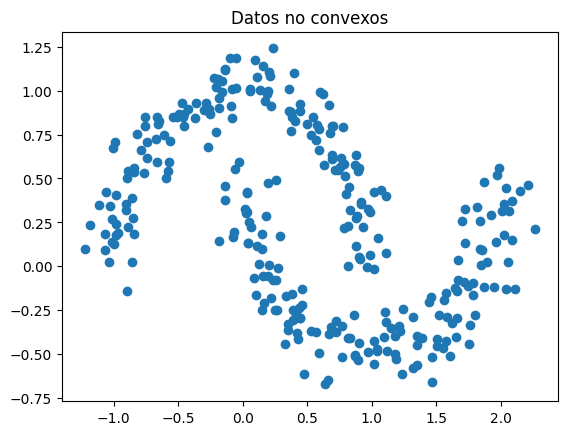

In [66]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.1)

plt.scatter(X[:,0], X[:,1])
plt.title("Datos no convexos")
plt.show()

In [67]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

sil = silhouette_score(X, labels)

print(f'Silhouette score: {sil:.4f}')

Silhouette score: 0.4681


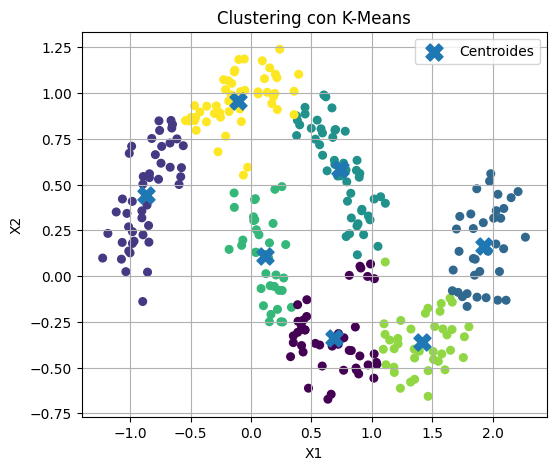

In [68]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:,0], centroids[:,1], s=150, marker='X', label='Centroides')
plt.title('Clustering con K-Means')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()

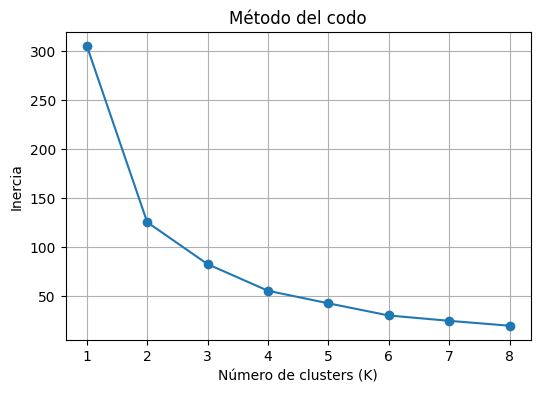

In [69]:
ks = range(1, 9)
inercias = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inercias.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(ks), inercias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()